In [ ]:
! pip install numpy==1.24.3 pmdarima statsmodels

In [ ]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import pmdarima as pm
from pmdarima.arima.utils import ndiffs
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

## Import Data

In [ ]:
df = pd.read_csv('final_data.csv')
df

,Kereta Api,Year,January,February,March,April,May,June,July,August,September,October,November,December
0,Jawa (Jabodetabek+Non Jabodetabek),2014,20698,19628,22427,21502,22547,23415,22125,22763,23219,24503,23986,25791
1,Jawa (Jabodetabek+Non Jabodetabek),2015,24254,22394,26841,26150,27450,27118,27077,27351,27125,28280,27253,29328
2,Jawa (Jabodetabek+Non Jabodetabek),2016,27886,26058,28156,28000,30176,28730,28216,29125,29019,29765,29178,31530
3,Jawa (Jabodetabek+Non Jabodetabek),2017,30359,26837,31612,30934,33157,30181,33669,33255,31921,34498,33798,36140
4,Jawa (Jabodetabek+Non Jabodetabek),2018,34107,30721,35272,35135,34877,32270,36089,34560,33878,35602,34637,37197
5,Jawa (Jabodetabek+Non Jabodetabek),2019,34435,31282,35068,35106,34514,34261,38303,34542,34615,35814,35228,36710
6,Jawa (Jabodetabek+Non Jabodetabek),2020,33472,31679,22949,5813,5476,9272,12205,12679,11295,11768,13523,13262
7,Jawa (Jabodetabek+Non Jabodetabek),2021,11631,11223,13995,14590,14627,14313,5646,6479,9510,13139,15161,17207
8,Jawa (Jabodetabek+Non Jabodetabek),2022,17499,12857,19133,19436,23114,23160,25272,23920,25167,27143,26473,29245
9,Jawa (Jabodetabek+Non Jabodetabek),2023,28435,25744,29249,27731,29886,29579,32372,30742,31067,33108,32424,34500


In [ ]:
df2 = pd.melt(df, id_vars=['Kereta Api', 'Year'], var_name='Month', value_name='Jumlah_Penumpang')
df2['Date'] = pd.to_datetime(df2['Month'] + ' ' + df2['Year'].astype(str))
df2 = df2[['Date', 'Jumlah_Penumpang']].sort_values(by='Date')
df2 = df2.reset_index()
df2

<ipython-input-4-654f65978e41>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df2['Date'] = pd.to_datetime(df2['Month'] + ' ' + df2['Year'].astype(str))


,index,Date,Jumlah_Penumpang
0,0,2014-01-01,20698
1,11,2014-02-01,19628
2,22,2014-03-01,22427
3,33,2014-04-01,21502
4,44,2014-05-01,22547
...,...,...,...
127,87,2024-08-01,35292
128,98,2024-09-01,34792
129,109,2024-10-01,37233
130,120,2024-11-01,34849


<Axes: xlabel='Date'>

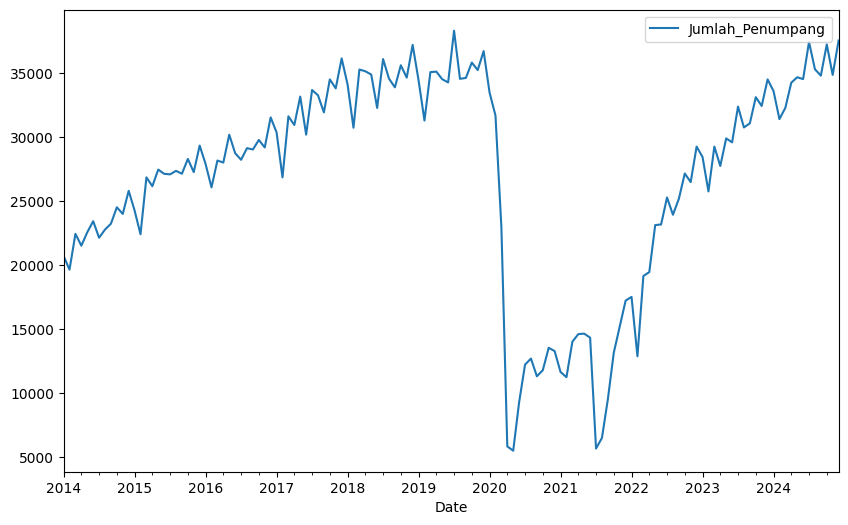

In [ ]:
df2.plot(x='Date', y='Jumlah_Penumpang', figsize=(10, 6))

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   index             132 non-null    int64         
 1   Date              132 non-null    datetime64[ns]
 2   Jumlah_Penumpang  132 non-null    int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 3.2 KB


In [ ]:
df2.Jumlah_Penumpang.describe()

,Jumlah_Penumpang
count,132.000000
mean,26860.886364
std,8287.347357
min,5476.000000
25%,22902.500000
50%,28874.500000
75%,33818.000000
max,38303.000000


## ADF Test

**Hipotesis**

**H0 : Data tidak stasioner**

**H1 : Data stasioner**

**Alpha : 0.05**



In [ ]:
adf_test = adfuller(df2.Jumlah_Penumpang)
print(f'ADF Stats : {adf_test[0]}')
print(f'p-value   : {adf_test[1]}')

ADF Stats : -1.7859895262998111
p-value   : 0.3874393541604581


DIFF 1

<Axes: xlabel='Date'>

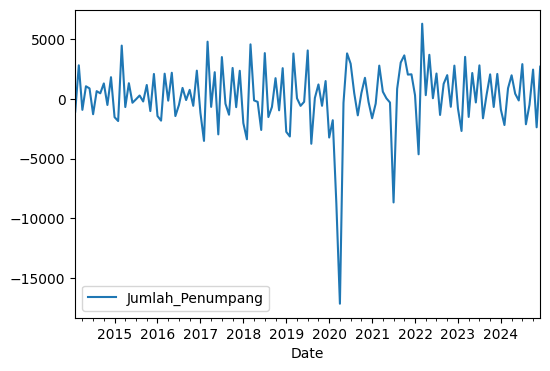

In [ ]:
df2_diff = df2.copy()
df2_diff['Jumlah_Penumpang'] = df2_diff['Jumlah_Penumpang'].diff()
df2_diff.dropna(inplace=True)
df2_diff.plot(x='Date', y='Jumlah_Penumpang', figsize=(6, 4))

In [ ]:
adf_test = adfuller(df2_diff.Jumlah_Penumpang)
print(f'ADF Stats : {adf_test[0]}')
print(f'p-value   : {adf_test[1]}')

ADF Stats : -2.713098648419045
p-value   : 0.07179892849052212


**DIFF 2**

<Axes: xlabel='Date'>

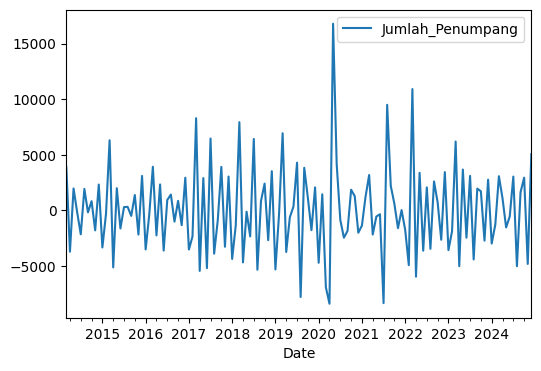

In [ ]:
df2_diff2 = df2.copy()
df2_diff2['Jumlah_Penumpang'] = df2_diff2['Jumlah_Penumpang'].diff().diff()
df2_diff2.dropna(inplace=True)
df2_diff2.plot(x='Date', y='Jumlah_Penumpang', figsize=(6, 4))

In [ ]:
adf_test = adfuller(df2_diff2.Jumlah_Penumpang)
print(f'ADF Stats : {adf_test[0]}')
print(f'p-value   : {adf_test[1]}')

ADF Stats : -5.889938268833992
p-value   : 2.940647054598914e-07


In [ ]:
# Menentukan diff menggunakan package pmarima

difs_adf = ndiffs(df2.Jumlah_Penumpang, test = "adf")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

In [ ]:
difs_adf

1

## ACF & PACF

**Original Data**

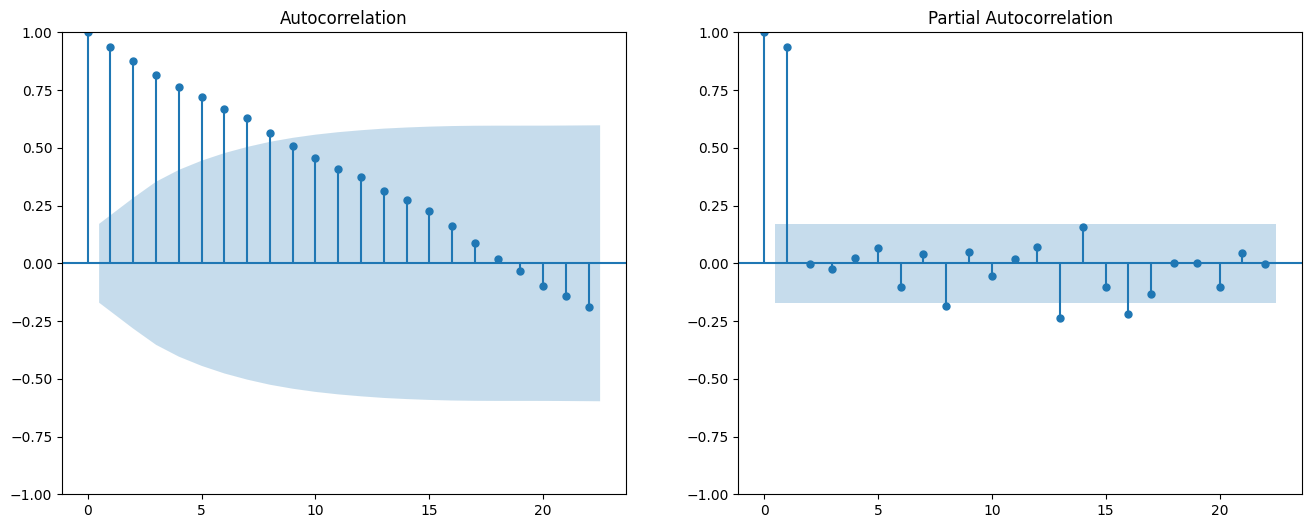

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
acf_original = plot_acf(df2.Jumlah_Penumpang, ax=ax1)
pacf_original = plot_pacf(df2.Jumlah_Penumpang, ax=ax2)

**DIFF 1**

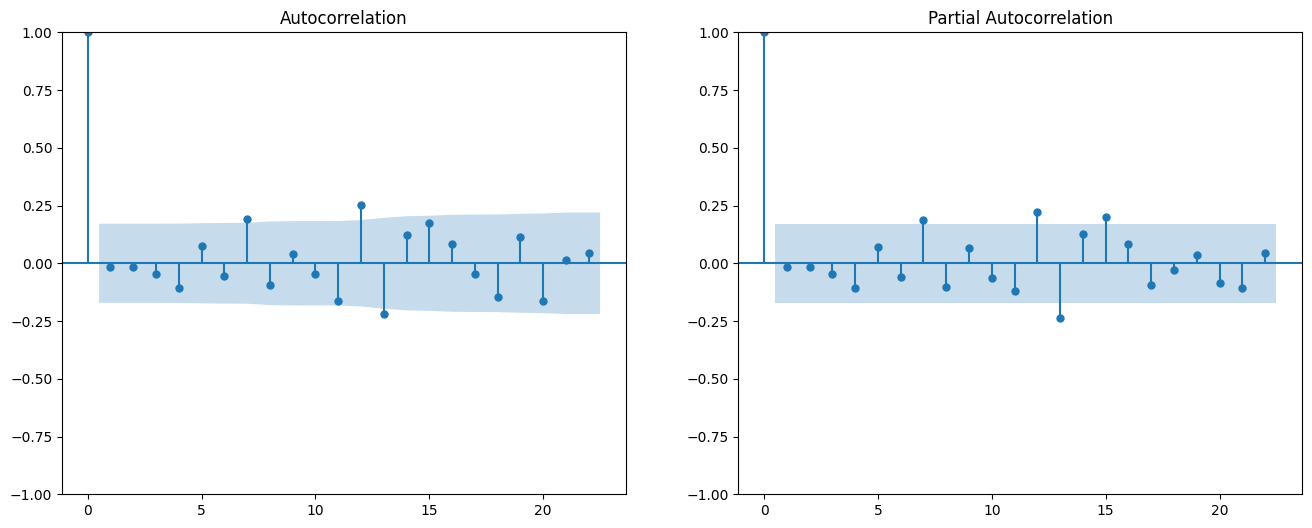

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
acf_original = plot_acf(df2_diff.Jumlah_Penumpang, ax=ax1)
pacf_original = plot_pacf(df2_diff.Jumlah_Penumpang, ax=ax2)

**DIFF 2**

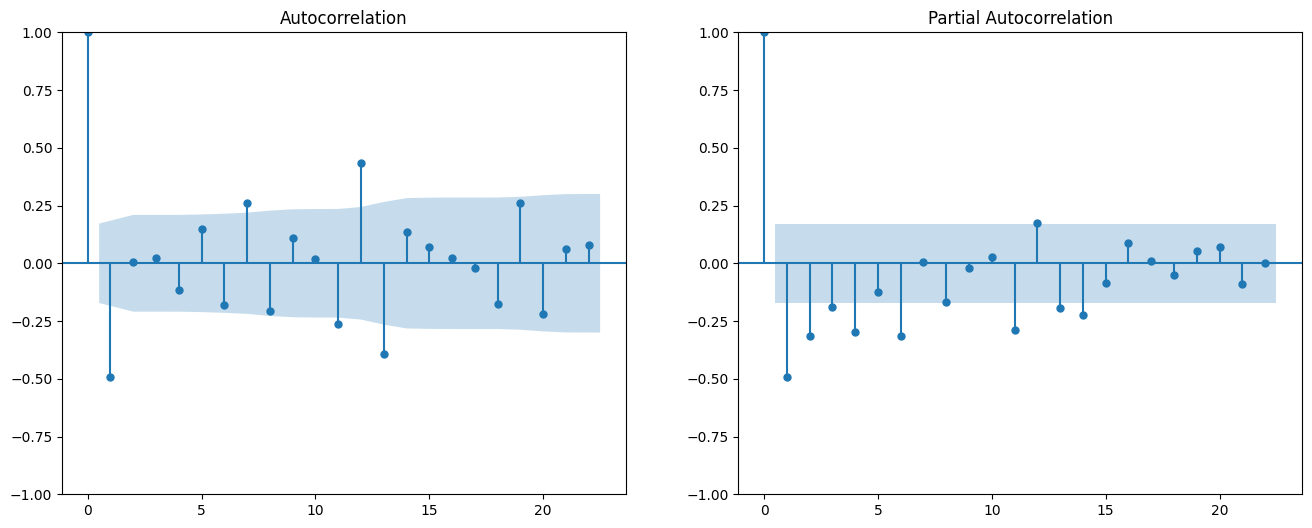

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
acf_original = plot_acf(df2_diff2.Jumlah_Penumpang, ax=ax1)
pacf_original = plot_pacf(df2_diff2.Jumlah_Penumpang, ax=ax2)

## Modelling

In [ ]:
# Splitting
train = df2.iloc[:-12]
test = df2.iloc[-12:]

### ARIMA (1,2,1)

**Manual Parameter (p, d, q) :**

*   **AR term (p)** : we will find out the required number of AR terms by inspecting the Partial Autocorrelation (PACF) plot.
*   **Differencing  (d)** : the value of d, therefore, is the minimum number of differencing needed to make the series stationary. If the time series is already stationary, then d = 0.
*  **MA term (q)** : we will look at the ACF plot for the number of MA terms. An MA term is technically, the error of the lagged forecast.








In [ ]:
model1 = ARIMA(train['Jumlah_Penumpang'], order=(1, 2, 1))
model1_fit = model1.fit()

print(model1_fit.summary())

                               SARIMAX Results                                
Dep. Variable:       Jumlah_Penumpang   No. Observations:                  120
Model:                 ARIMA(1, 2, 1)   Log Likelihood               -1113.143
Date:                Thu, 27 Mar 2025   AIC                           2232.286
Time:                        07:07:03   BIC                           2240.598
Sample:                             0   HQIC                          2235.661
                                - 120                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1260      0.079      1.588      0.112      -0.030       0.282
ma.L1         -0.9992      0.110     -9.109      0.000      -1.214      -0.784
sigma2      8.793e+06   1.27e-08   6.93e+14      0.0

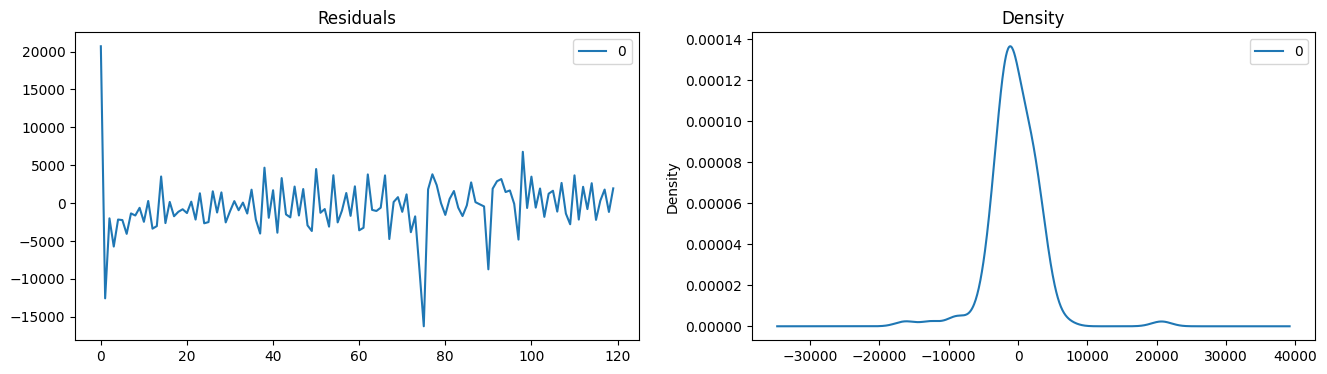

In [ ]:
residuals = pd.DataFrame(model1_fit.resid)

fig, ax = plt.subplots(1,2, figsize=(16, 4))
residuals.plot(y=0,title='Residuals', ax=ax[0])
residuals.plot(title='Density', kind='kde', ax=ax[1])
plt.show()

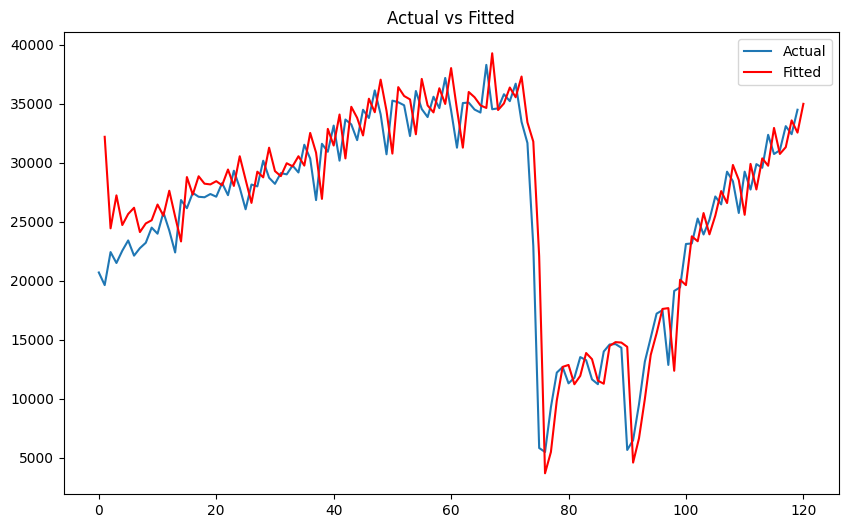

In [ ]:
# Actual vs Fitted

predictions = model1_fit.get_prediction(start=1, end=120)
plt.figure(figsize=(10, 6))
plt.plot(train['Jumlah_Penumpang'], label='Actual')
plt.plot(predictions.predicted_mean, label='Fitted', color='red')
plt.title("Actual vs Fitted")
plt.legend()
plt.show()

RMSE: 2122.87
MAE: 1831.81
MAPE: 0.05


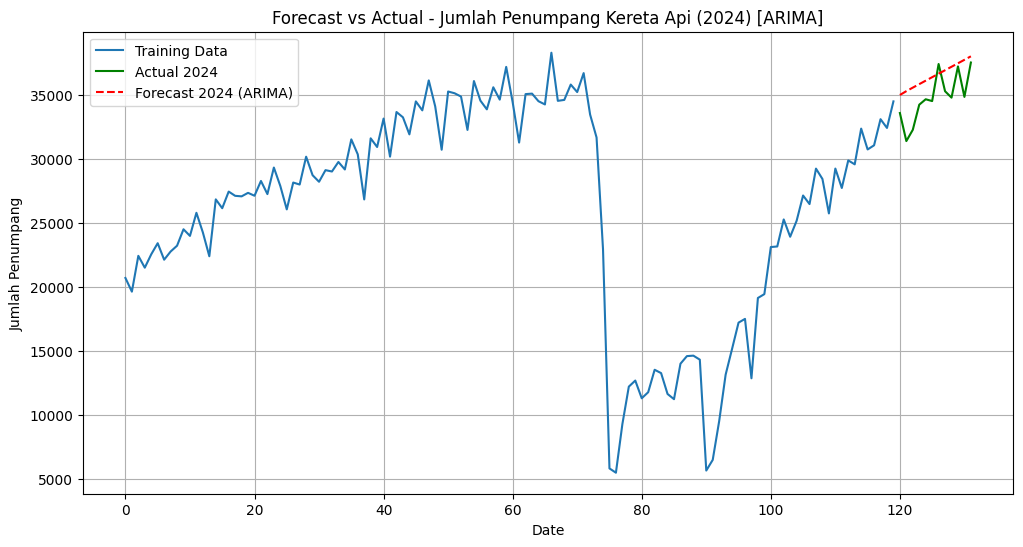

In [ ]:
forecast = model1_fit.forecast(steps=12)

mae = mean_absolute_error(test['Jumlah_Penumpang'], forecast)
mape = mean_absolute_percentage_error(test['Jumlah_Penumpang'], forecast)
rmse = np.sqrt(mean_squared_error(test['Jumlah_Penumpang'], forecast))

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}")

result_df = pd.DataFrame({
    'Actual': test['Jumlah_Penumpang'].values,
    'Predicted': forecast
}, index=test.index)

plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Jumlah_Penumpang'], label='Training Data')
plt.plot(test.index, test['Jumlah_Penumpang'], label='Actual 2024', color='green')
plt.plot(test.index, forecast, label='Forecast 2024 (ARIMA)', color='red', linestyle='--')
plt.title('Forecast vs Actual - Jumlah Penumpang Kereta Api (2024) [ARIMA]')
plt.xlabel('Date')
plt.ylabel('Jumlah Penumpang')
plt.legend()
plt.grid()
plt.show()

### ARIMA (1,1,1)

In [ ]:
model2 = ARIMA(train['Jumlah_Penumpang'], order=(1,1,1))
model2_fit = model2.fit()

print(model2_fit.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:       Jumlah_Penumpang   No. Observations:                  120
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1115.332
Date:                Thu, 27 Mar 2025   AIC                           2236.663
Time:                        07:07:05   BIC                           2245.000
Sample:                             0   HQIC                          2240.049
                                - 120                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4288      3.208     -0.134      0.894      -6.717       5.859
ma.L1          0.4062      3.248      0.125      0.900      -5.960       6.772
sigma2       8.28e+06   8.08e+05     10.253      0.0

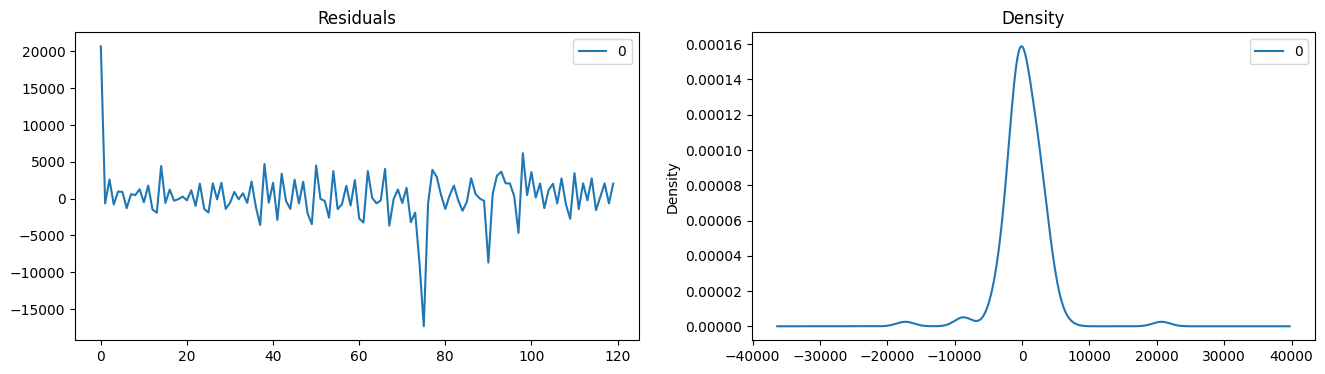

In [ ]:
residuals = pd.DataFrame(model2_fit.resid)

fig, ax = plt.subplots(1,2, figsize=(16, 4))
residuals.plot(y=0,title='Residuals', ax=ax[0])
residuals.plot(title='Density', kind='kde', ax=ax[1])
plt.show()

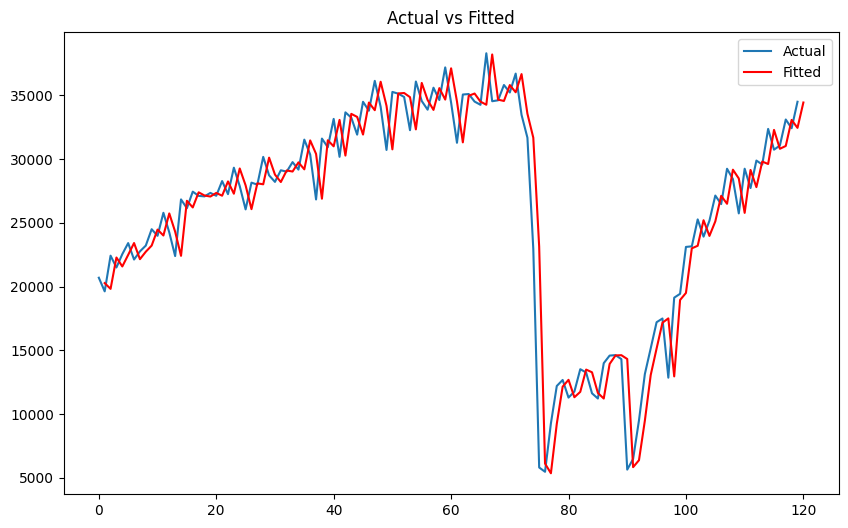

In [ ]:
# Actual vs Fitted

predictions = model2_fit.get_prediction(start=1, end=120)
plt.figure(figsize=(10, 6))
plt.plot(train['Jumlah_Penumpang'], label='Actual')
plt.plot(predictions.predicted_mean, label='Fitted', color='red')
plt.title("Actual vs Fitted")
plt.legend()
plt.show()

RMSE: 1868.47
MAE: 1413.43
MAPE: 0.04


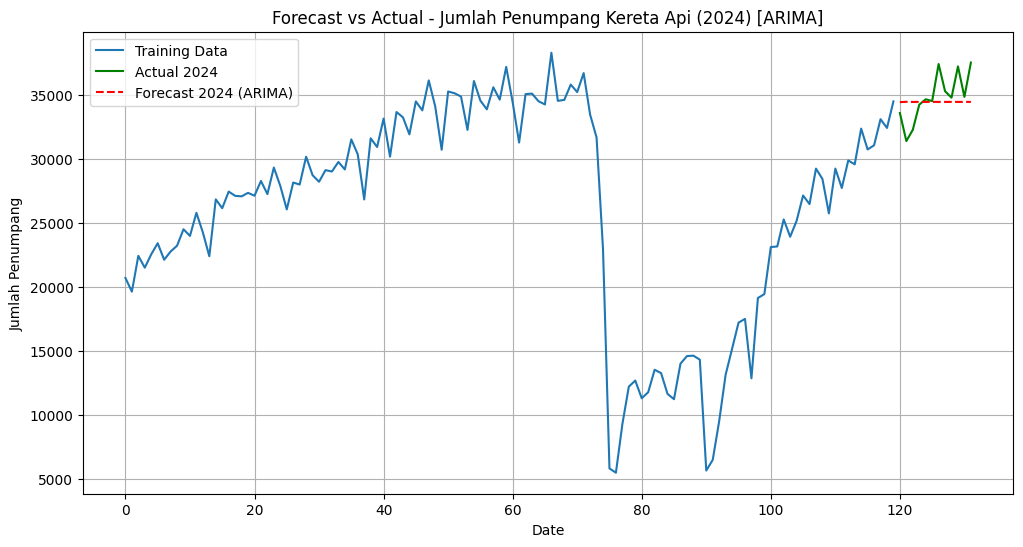

In [ ]:
forecast = model2_fit.forecast(steps=12)

mae = mean_absolute_error(test['Jumlah_Penumpang'], forecast)
mape = mean_absolute_percentage_error(test['Jumlah_Penumpang'], forecast)
rmse = np.sqrt(mean_squared_error(test['Jumlah_Penumpang'], forecast))

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}")

result_df = pd.DataFrame({
    'Actual': test['Jumlah_Penumpang'].values,
    'Predicted': forecast
}, index=test.index)

plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Jumlah_Penumpang'], label='Training Data')
plt.plot(test.index, test['Jumlah_Penumpang'], label='Actual 2024', color='green')
plt.plot(test.index, forecast, label='Forecast 2024 (ARIMA)', color='red', linestyle='--')
plt.title('Forecast vs Actual - Jumlah Penumpang Kereta Api (2024) [ARIMA]')
plt.xlabel('Date')
plt.ylabel('Jumlah Penumpang')
plt.legend()
plt.grid()
plt.show()

### AUTO ARIMA

In [ ]:
# Fit the ARIMA model using auto_arima
auto_model = pm.auto_arima(
    train['Jumlah_Penumpang'],
    start_p=1,
    start_q=1,
    test='adf',       # use adftest to find optimal 'd'
    max_p=5, max_q=5, # maximum p and q
    m=1,              # frequency of series
    d=None,           # let model determine 'd'
    seasonal=False,   # No seasonality
    start_P=0,
    D=0,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2238.476, Time=0.63 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2234.534, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2236.507, Time=0.07 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2236.538, Time=0.19 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2232.736, Time=0.03 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.978 seconds


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  120
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -1115.368
Date:                Thu, 27 Mar 2025   AIC                           2232.736
Time:                        07:07:08   BIC                           2235.515
Sample:                             0   HQIC                          2233.865
                                - 120                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      8.036e+06   4.15e+05     19.341      0.000    7.22e+06    8.85e+06
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               663.44
Prob(Q):                              0.97   Pr

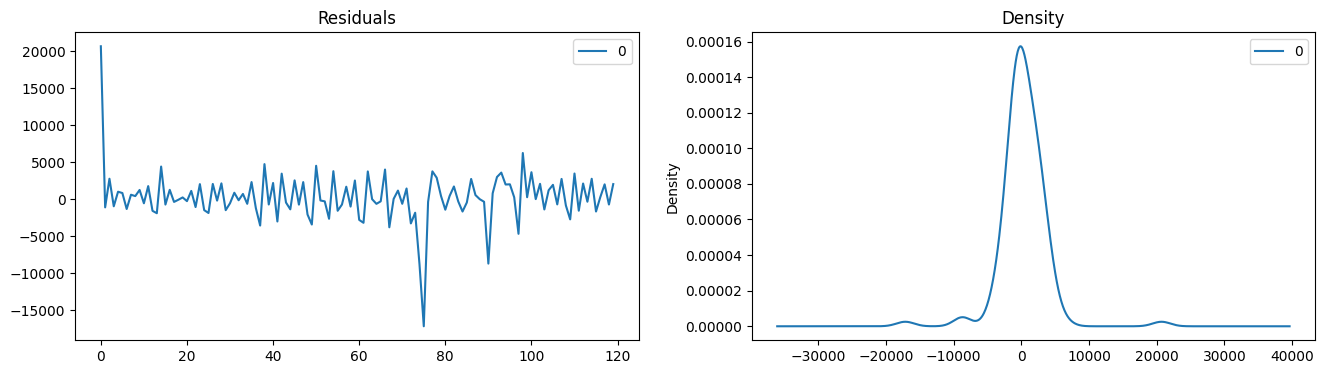

In [ ]:
residuals = pd.DataFrame(auto_model.resid())

fig, ax = plt.subplots(1,2, figsize=(16, 4))
residuals.plot(y=0,title='Residuals', ax=ax[0])
residuals.plot(title='Density', kind='kde', ax=ax[1])
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


RMSE: 1860.97
MAE: 1400.75
MAPE: 0.04


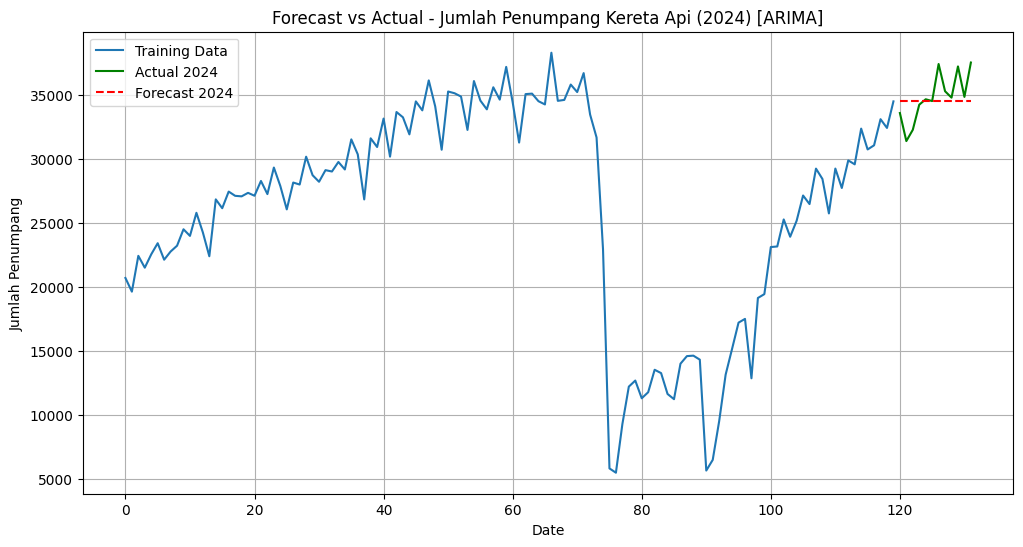

In [ ]:
forecast = auto_model.predict(n_periods=12)

mae = mean_absolute_error(test['Jumlah_Penumpang'], forecast)
mape = mean_absolute_percentage_error(test['Jumlah_Penumpang'], forecast)
rmse = np.sqrt(mean_squared_error(test['Jumlah_Penumpang'], forecast))

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}")

result_df = pd.DataFrame({
    'Actual': test['Jumlah_Penumpang'].values,
    'Predicted': forecast
}, index=test.index)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Jumlah_Penumpang'], label='Training Data')  # Training data
plt.plot(test.index, test['Jumlah_Penumpang'], label='Actual 2024', color='green')  # Actual test data
plt.plot(test.index, forecast, label='Forecast 2024', color='red', linestyle='--')  # Forecast data

# Add title and labels
plt.title('Forecast vs Actual - Jumlah Penumpang Kereta Api (2024) [ARIMA]')
plt.xlabel('Date')
plt.ylabel('Jumlah Penumpang')
plt.legend()
plt.grid(True)

# Show plot
plt.show()


### SARIMAX

In [ ]:
model4 = SARIMAX(train['Jumlah_Penumpang'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model4_fit = model4.fit(disp=False)

print(model4_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                   Jumlah_Penumpang   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1004.297
Date:                            Thu, 27 Mar 2025   AIC                           2018.594
Time:                                    07:07:17   BIC                           2031.958
Sample:                                         0   HQIC                          2024.012
                                            - 120                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1429      0.530     -0.270      0.787      -1.181       0.896
ma.L1          0.3676      0.481   

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


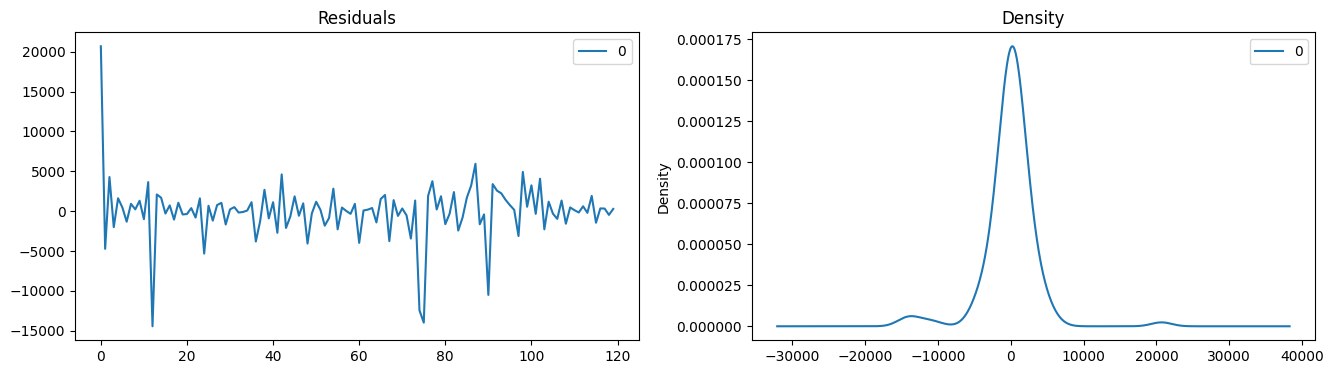

In [ ]:
residuals = pd.DataFrame(model4_fit.resid)

fig, ax = plt.subplots(1,2, figsize=(16, 4))
residuals.plot(y=0,title='Residuals', ax=ax[0])
residuals.plot(title='Density', kind='kde', ax=ax[1])
plt.show()

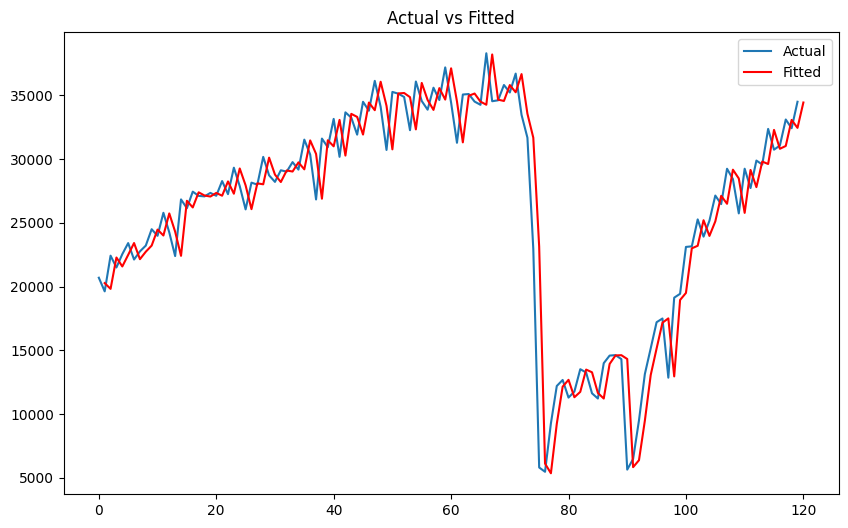

In [ ]:
# Actual vs Fitted

predictions = model2_fit.get_prediction(start=1, end=120)
plt.figure(figsize=(10, 6))
plt.plot(train['Jumlah_Penumpang'], label='Actual')
plt.plot(predictions.predicted_mean, label='Fitted', color='red')
plt.title("Actual vs Fitted")
plt.legend()
plt.show()

RMSE: 1200.97
MAE: 945.61
MAPE: 0.03


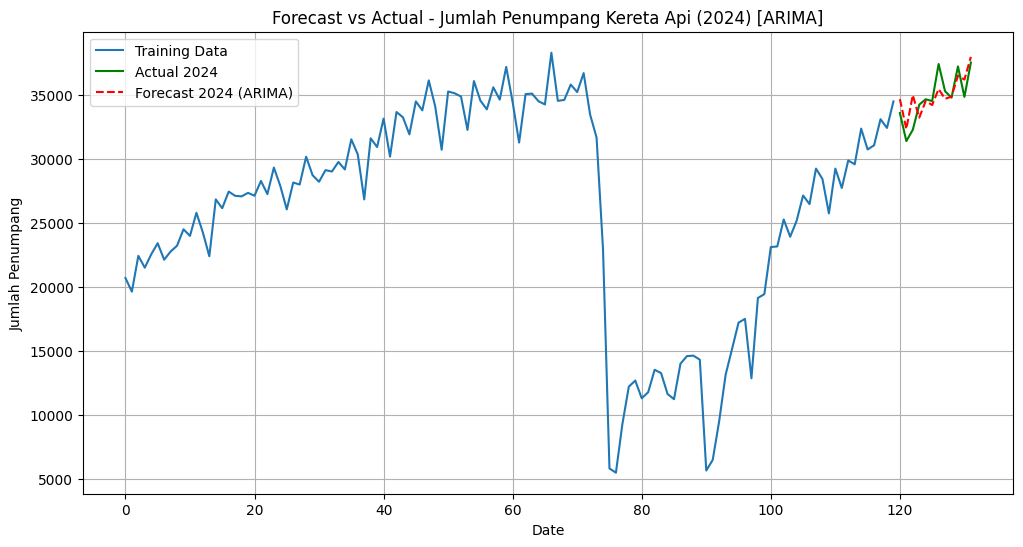

In [ ]:
forecast = model4_fit.forecast(steps=12)

mae = mean_absolute_error(test['Jumlah_Penumpang'], forecast)
mape = mean_absolute_percentage_error(test['Jumlah_Penumpang'], forecast)
rmse = np.sqrt(mean_squared_error(test['Jumlah_Penumpang'], forecast))

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}")

result_df = pd.DataFrame({
    'Actual': test['Jumlah_Penumpang'].values,
    'Predicted': forecast
}, index=test.index)

plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Jumlah_Penumpang'], label='Training Data')
plt.plot(test.index, test['Jumlah_Penumpang'], label='Actual 2024', color='green')
plt.plot(test.index, forecast, label='Forecast 2024 (ARIMA)', color='red', linestyle='--')
plt.title('Forecast vs Actual - Jumlah Penumpang Kereta Api (2024) [ARIMA]')
plt.xlabel('Date')
plt.ylabel('Jumlah Penumpang')
plt.legend()
plt.grid()
plt.show()

## UJI ASUMSI BEST MODEL

In [ ]:
import scipy.stats as stats
from statsmodels.stats.diagnostic import lilliefors
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

residuals = model4_fit.resid

# 1. Uji Durbin-Watson (Autokorelasi)
dw_statistic = durbin_watson(residuals)
print("Durbin-Watson Statistic:")
print(f"Nilai DW: {dw_statistic}")
print("Interpretasi:")
print("- Jika DW mendekati 2: Tidak ada autokorelasi")
print("- DW < 1.5: Indikasi autokorelasi positif")
print("- DW > 2.5: Indikasi autokorelasi negatif")

Durbin-Watson Statistic:
Nilai DW: 1.9822051859966048
Interpretasi:
- Jika DW mendekati 2: Tidak ada autokorelasi
- DW < 1.5: Indikasi autokorelasi positif
- DW > 2.5: Indikasi autokorelasi negatif


In [ ]:
# 2. Uji Normalitas Residual (Shapiro-Wilk)
shapiro_test = stats.shapiro(residuals)
print("Uji Shapiro-Wilk:")
print(f"Statistik: {shapiro_test.statistic}")
print(f"p-value: {shapiro_test.pvalue}")
print("Interpretasi:")
print("- H0: Residual terdistribusi normal")
print("- Jika p-value > 0.05: Residual normal")

Uji Shapiro-Wilk:
Statistik: 0.7603116922252471
p-value: 1.0247701243988584e-12
Interpretasi:
- H0: Residual terdistribusi normal
- Jika p-value > 0.05: Residual normal


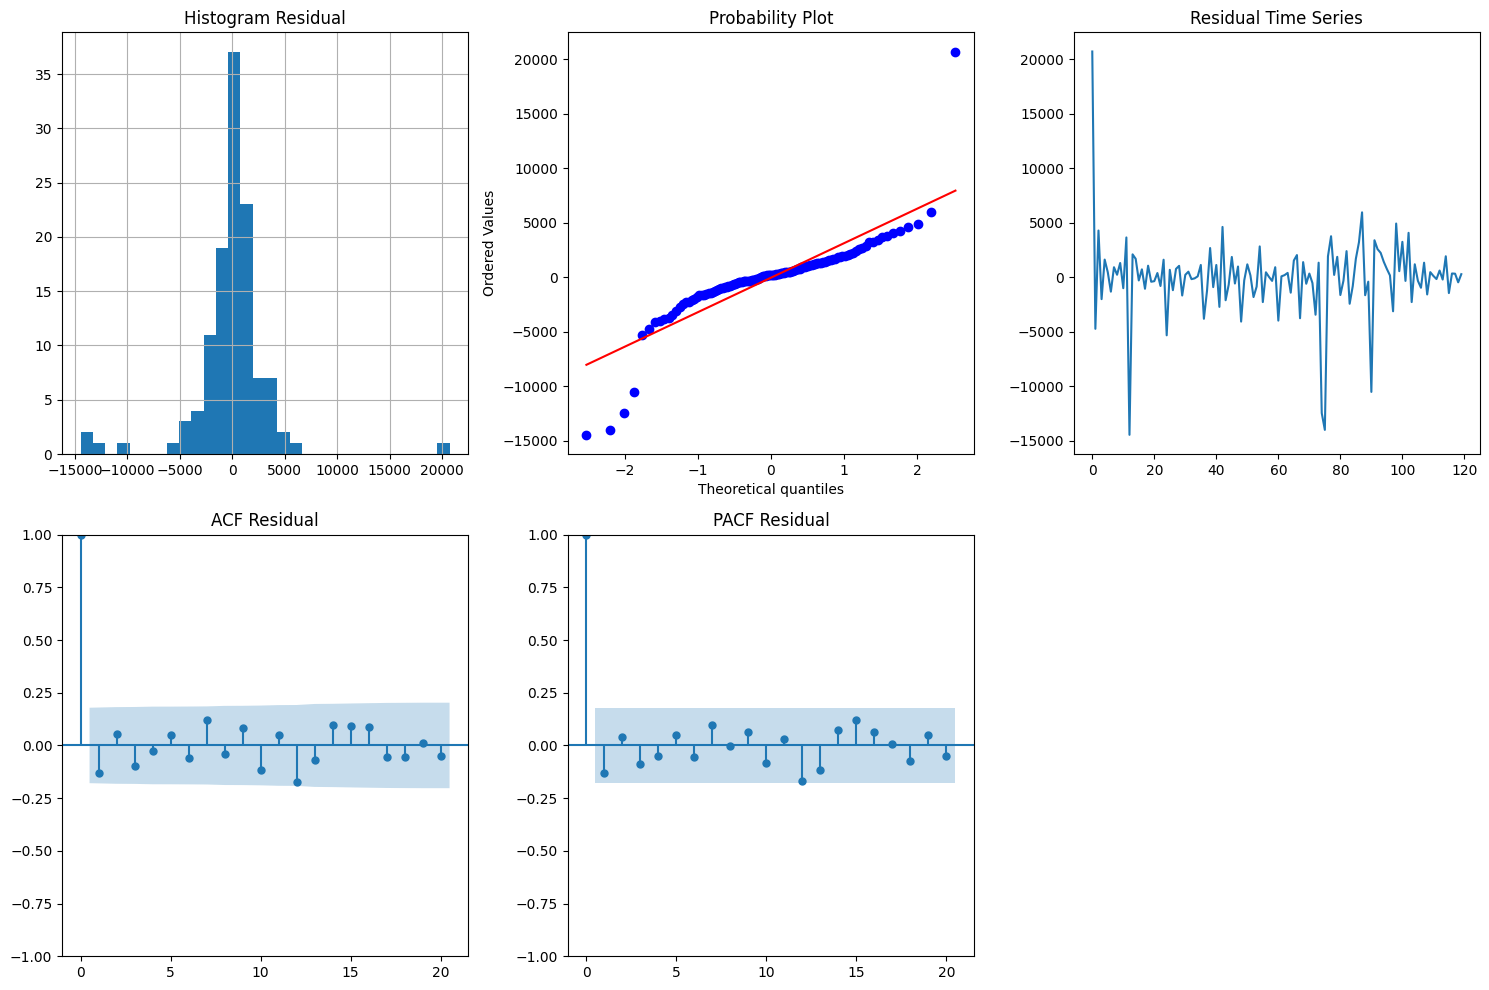

In [ ]:
# Visualisasi Residual
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(15,10))
plt.subplot(231)
plt.title('Histogram Residual')
residuals.hist(bins=30)

plt.subplot(232)
plt.title('Q-Q Plot Residual')
from scipy.stats import probplot
probplot(residuals, plot=plt)

plt.subplot(233)
plt.title('Residual Time Series')
residuals.plot()

# Tambahkan ACF Residual
plt.subplot(234)
ax_acf = plt.gca()
plot_acf(residuals, lags=20, ax=ax_acf)
ax_acf.set_title('ACF Residual')

# Tambahkan PACF Residual
plt.subplot(235)
ax_pacf = plt.gca()
plot_pacf(residuals, lags=20, ax=ax_pacf)
ax_pacf.set_title('PACF Residual')

plt.tight_layout()
plt.show()

## FORECASTING 2025

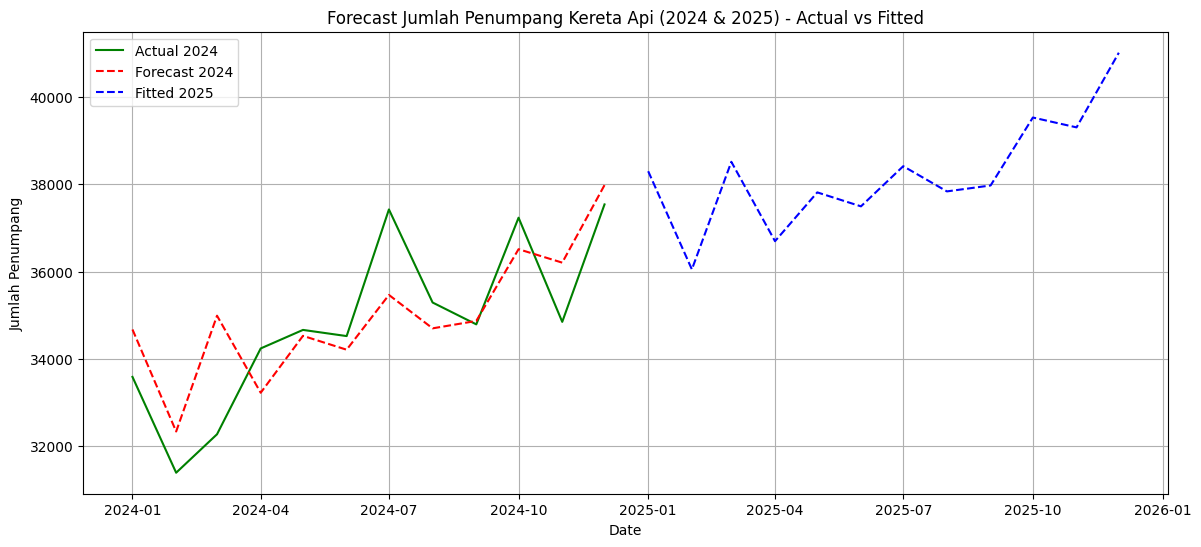

In [ ]:
forecast_24bulan = model4_fit.forecast(steps=24)

forecast_2024 = forecast_24bulan[:12]
forecast_2025 = forecast_24bulan[12:]

forecast_index_2024 = pd.date_range(start='2024-01-01', periods=12, freq='MS')
forecast_index_2025 = pd.date_range(start='2025-01-01', periods=12, freq='MS')

result_2024 = pd.DataFrame({
    'Actual': test['Jumlah_Penumpang'].values,
    'Predicted': forecast_2024
}, index=forecast_index_2024)

plt.figure(figsize=(14, 6))
plt.plot(result_2024.index, result_2024['Actual'], label='Actual 2024', color='green')
plt.plot(forecast_index_2024, forecast_2024, label='Forecast 2024', color='red', linestyle='--')
plt.plot(forecast_index_2025, forecast_2025, label='Fitted 2025', color='blue', linestyle='--')
plt.title('Forecast Jumlah Penumpang Kereta Api (2024 & 2025) - Actual vs Fitted')
plt.xlabel('Date')
plt.ylabel('Jumlah Penumpang')
plt.legend()
plt.grid(True)
plt.show()